# 02. 결과 분석

모델 비교와 선정 근거, 피크 예측 성능, 오류 분석을 정리한다. `python run.py`의 결과(`outputs/`)를 사용한다.

피크 지표는 일자별 상위 K개(기본 10개) 15분 구간으로 정의한다.
- `top10_hit`: 예측 상위 10개 구간 중 실제 상위 10개에 포함된 비율(순위 무관, 실제값 동률은 모두 포함)
- `top10_hit_within_15min`: top10_hit에서 실제 상위 10개 구간 15분 이내까지 허용했을 때의 비율
- `top10_mae`: 실제·예측 상위 10개 값을 각각 내림차순 정렬해 순위끼리 비교한 MAE(발생 시각과 무관한 피크 수준 오차)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.experiment import wavg, error_slices
from src.metrics import K, HIT_COL, TOL_HIT_COL, TOPK_MAE_COL, daily_matrix, topk_scores, selection_score
from src.report import cv_summary
from src.viz import setup_plot_style, DOW_KR

setup_plot_style()
pd.set_option("display.max_columns", 50)
OUT = ROOT / C.OUTPUT_DIR

required = ["metrics_cv.csv", "metrics_test.csv", "predictions_test.csv", "run_info.json"]
missing = [f for f in required if not (OUT / f).exists()]
if missing:
    raise FileNotFoundError(f"run.py 실행 결과가 없습니다: {missing}")

cv = pd.read_csv(OUT / "metrics_cv.csv")
test = pd.read_csv(OUT / "metrics_test.csv")
preds = pd.read_csv(OUT / "predictions_test.csv", parse_dates=["ts", "date"])
info = json.loads((OUT / "run_info.json").read_text(encoding="utf-8"))
selected = info["selected_model"]
print("GBM 백엔드:", info["gbm_backend"], "/ 선정 모델:", selected)

GBM 백엔드: lightgbm 4.6.0 / 선정 모델: lstm_1d


## 1. 교차검증

7/5부터 주 단위 walk-forward 7개 폴드. 폴드별 지표를 채점일 수로 가중평균한다. 선정 기준은 점예측 모델 중 CV MAE 최소이다.

,model,lookback,mae,rmse,daily_max_mae,top10_hit,top10_hit_within_15min,top10_mae,mae_std_across_folds
2,lstm_1d,1d,18.650,28.242,31.366,0.369,0.585,28.857,15.281
3,lstm_7d,7d,22.430,35.584,34.851,0.373,0.598,32.475,17.286
1,gbm_1d,1d,23.749,35.389,36.879,0.354,0.567,32.911,10.015
0,gbm,7d,24.696,33.500,41.953,0.381,0.573,38.149,18.684
4,random_forest,7d,26.932,38.458,45.521,0.337,0.533,41.391,22.940


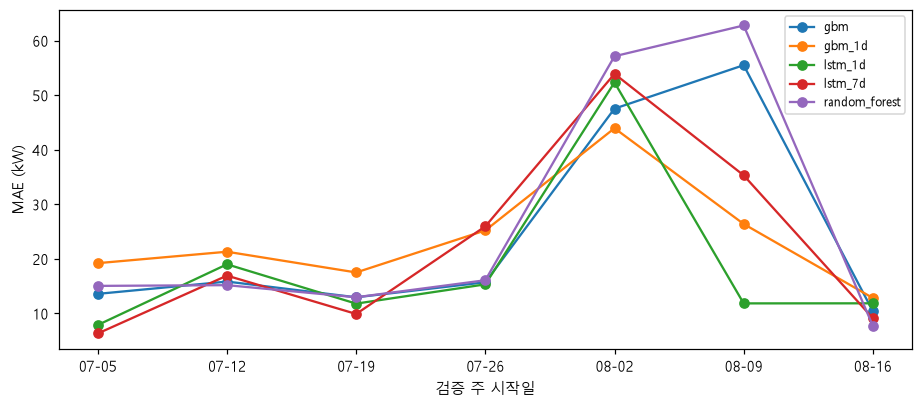

In [2]:
cv_mean = cv_summary(cv)
display(cv_mean[["model", "lookback", "mae", "rmse", "daily_max_mae", HIT_COL, TOL_HIT_COL, TOPK_MAE_COL,
                 "mae_std_across_folds"]].round(3))

ax = cv.pivot(index="fold", columns="model", values="mae").plot(marker="o", figsize=(10, 4))
ax.set_ylabel("MAE (kW)")
ax.set_xlabel("검증 주 시작일")
ax.legend(fontsize=8)
plt.show()

08-02, 08-09 폴드는 휴가 주간과 그다음 주로, 7일 전 값에 의존하는 모델의 오차가 크게 증가한다.

## 2. 최종 모델 선정

최종 모델 선정은 다음과 같은 과정을 거쳐 이루어졌다.

- 우선 교차검증의 평가 지표 5가지(mae, rmse, top10_mae, top10_hit, top10_hit_within_15min)를 먼저 정규화한다.
- 그 다음 mae, rmse, top10_mae 3가지 정규화된 값의 평균에 -1을 곱한 뒤 top10_hit, top10_hit_within_15min 2가지 정규화된 값의 평균과 더해서 점수를 산출한다.
- 마지막으로 해당 점수가 가장 높은 모델을 최종 모델로 선정한다.

,mae,rmse,top10_mae,top10_hit,top10_hit_within_15min,error_z,hit_z,score
model,,,,,,,,
lstm_1d,18.650,28.242,28.857,0.369,0.585,1.426,0.460,0.943
lstm_7d,22.430,35.584,32.475,0.373,0.598,0.128,0.837,0.482
gbm,24.696,33.500,38.149,0.381,0.573,-0.315,0.565,0.125
gbm_1d,23.749,35.389,32.911,0.354,0.567,-0.027,-0.347,-0.187
random_forest,26.932,38.458,41.391,0.337,0.533,-1.211,-1.514,-1.363


최종 선정 모델: lstm_1d


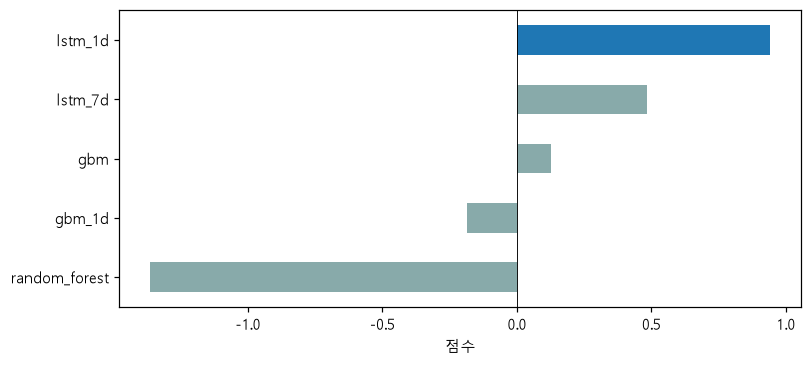

In [3]:
lower = ["mae", "rmse", TOPK_MAE_COL]
higher = [HIT_COL, TOL_HIT_COL]
cv_tbl = cv_mean.set_index("model")
sc = selection_score(cv_tbl, lower, higher).sort_values("score", ascending=False)
final_model = sc["score"].idxmax()
display(cv_tbl.loc[sc.index, lower + higher].join(sc).round(3))
print("최종 선정 모델:", final_model)

s = sc["score"].sort_values()
ax = s.plot(kind="barh", figsize=(8, 3.5), color=["tab:blue" if m == final_model else "#8aa" for m in s.index])
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("점수")
ax.set_ylabel("")
plt.show()

## 3. 최종 테스트 (8/23~9/14)

,model,lookback,mae,rmse,daily_max_mae,top10_hit,top10_hit_within_15min,top10_mae
0,random_forest,7d,10.554,16.479,18.160,0.439,0.691,14.357
1,gbm_1d,1d,18.884,26.846,24.170,0.439,0.700,22.294
2,gbm,7d,12.558,19.387,18.287,0.439,0.696,15.805
3,lstm_1d,1d,8.593,12.150,10.994,0.457,0.730,8.305
4,lstm_7d,7d,8.167,11.747,9.984,0.426,0.670,7.731


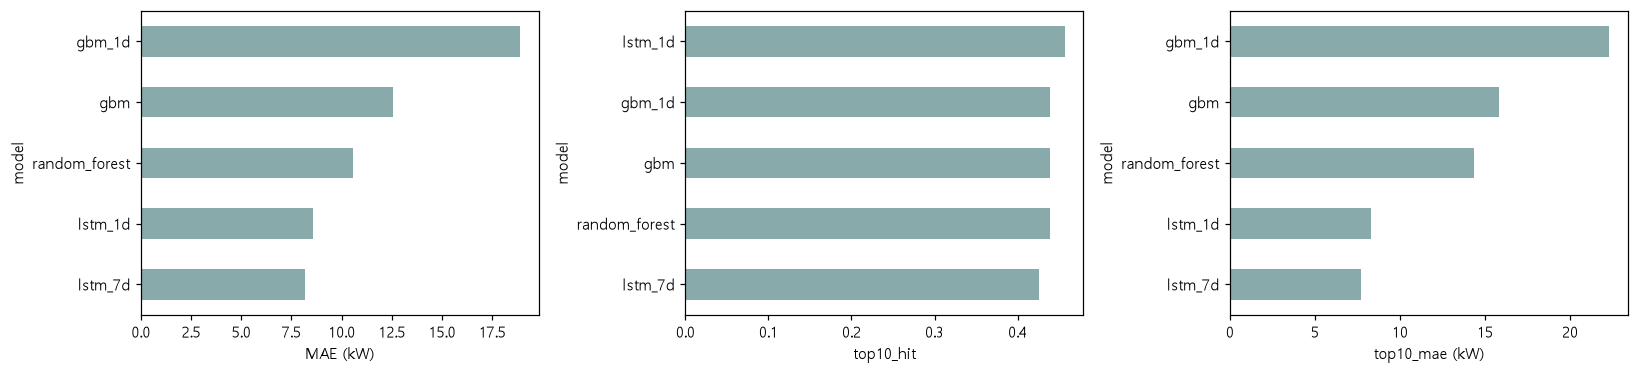

In [4]:
display(test[["model","lookback", "mae", "rmse", "daily_max_mae",
              HIT_COL, TOL_HIT_COL, TOPK_MAE_COL]].round(3))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
t = test.set_index("model")
for ax, col, xlabel in [(axes[0], "mae", "MAE (kW)"), (axes[1], HIT_COL, HIT_COL), (axes[2], TOPK_MAE_COL, f"{TOPK_MAE_COL} (kW)")]:
    t[col].sort_values().plot(kind="barh", ax=ax, color="#8aa")
    ax.set_xlabel(xlabel)
plt.tight_layout()
plt.show()

테스트 구간은 정상 운영 주간으로만 구성되어 휴가 주간이 포함된 CV보다 오차가 작다.

## 4. 테스트 예측

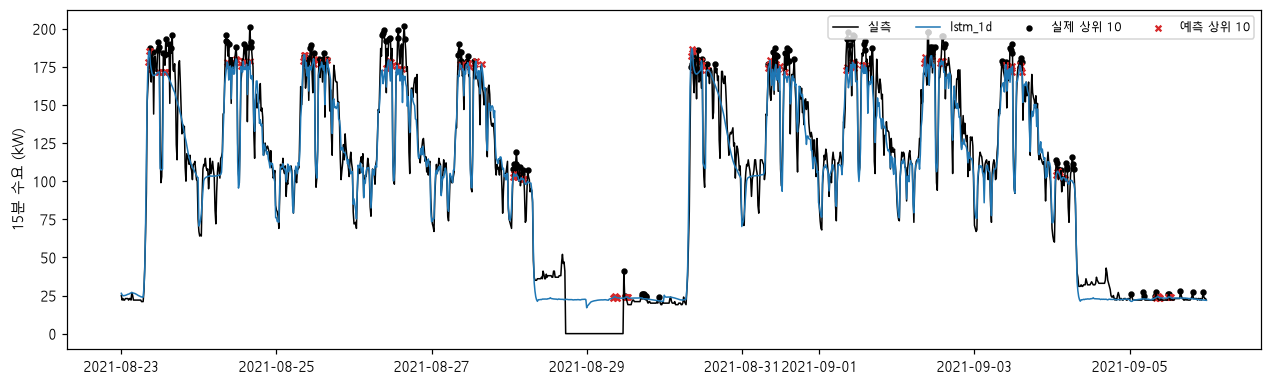

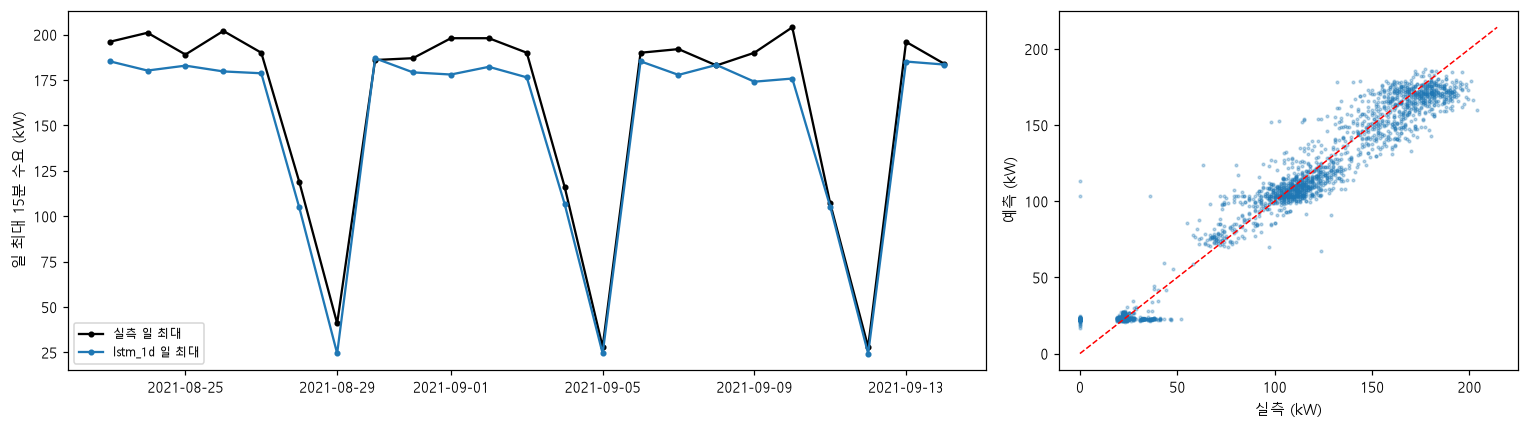

In [5]:
w = preds[preds["ts"] < preds["ts"].min().normalize() + pd.Timedelta(days=14)].reset_index(drop=True)
a = daily_matrix(w, "kw").to_numpy()
p = daily_matrix(w, selected).to_numpy()
pos = lambda m: (np.arange(len(m))[:, None] * 96 + np.argsort(-m, axis=1, kind="stable")[:, :K]).ravel()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(w["ts"], w["kw"], color="black", lw=1, label="실측")
ax.plot(w["ts"], w[selected], lw=1, label=selected)
ax.scatter(w.loc[pos(a), "ts"], w.loc[pos(a), "kw"], s=10, color="black", label=f"실제 상위 {K}")
ax.scatter(w.loc[pos(p), "ts"], w.loc[pos(p), selected], s=14, marker="x", color="tab:red", label=f"예측 상위 {K}")
ax.set_ylabel("15분 수요 (kW)")
ax.legend(ncol=4, fontsize=8, loc="upper right")
plt.show()

daily = preds.groupby("date")[["kw", selected]].max()
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(daily.index, daily["kw"], "o-", color="black", ms=3, label="실측 일 최대")
axes[0].plot(daily.index, daily[selected], "o-", ms=3, label=f"{selected} 일 최대")
axes[0].set_ylabel("일 최대 15분 수요 (kW)")
axes[0].legend(fontsize=8)
axes[1].scatter(preds["kw"], preds[selected], s=3, alpha=0.3)
lim = [0, preds["kw"].max() * 1.05]
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].set_xlabel("실측 (kW)")
axes[1].set_ylabel("예측 (kW)")
plt.tight_layout()
plt.show()

## 5. 오류 분석

오차의 크기는 요일별, 시간별로 다른 패턴을 보였다.

우선 요일별로 봤을 때 아래 표의 모든 지표에서 가장 낮은 오차를 보인 요일은 일요일이었다. 이는 일요일에 공장 가동을 최소한으로 유지하기 때문에 비교적 단순한 패턴을 보여 예측에 용이했기 때문으로 판단된다.

다음으로 시간대별 오차의 경우 주간이 야간보다 더 높은 경향을 보인다.
주간 시간대에 공장 설비 가동률이 가장 높기 때문에 전력 사용량의 편차가 크게 나타났고, 이는 모델의 예측을 주간 시간대에 대하여 더 어렵게 만들었다고 추정된다.

또한, 점심시간, 출퇴근 시간과 같이 전력량이 급격하게 변하는 부분에도 다소 오차가 큰 것으로 나타났다.

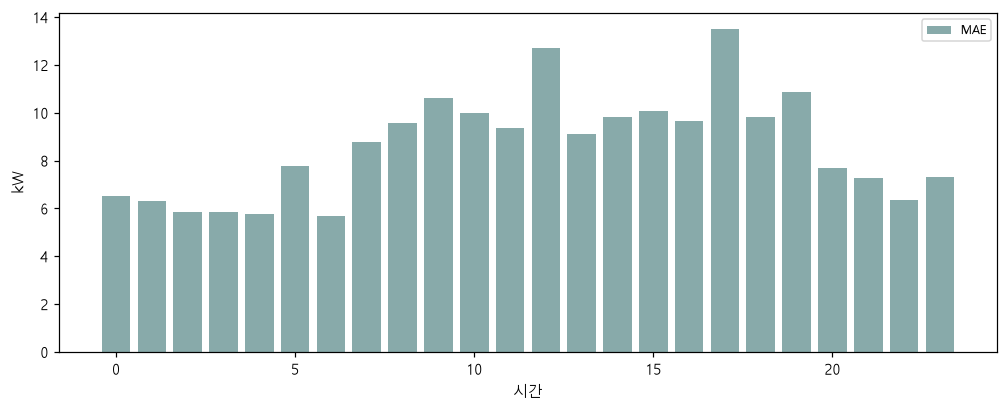

,dow,mae,n,top10_hits,top10_hits_within_15min,top10_mae,요일
0,1,9.16,384,5.50,8.50,7.99,월
1,2,9.78,384,4.50,7.75,9.13,화
2,3,10.25,288,4.33,6.67,7.40,수
3,4,9.10,288,4.00,7.00,14.23,목
4,5,7.79,288,5.33,8.33,11.25,금
5,6,8.87,288,6.33,8.67,5.52,토
6,7,4.62,288,1.67,3.67,2.45,일


In [6]:
sl = error_slices(preds, selected)
h = sl["by_hour"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(h["hour"], h["mae"], color="#8aa", label="MAE")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("시간")
ax.set_ylabel("kW")
ax.legend(fontsize=8)
plt.show()

display(sl["by_dow"].assign(요일=lambda d: d["dow"].map(DOW_KR)).round(2))

### 피크 시간대 적중

실제 상위 10개 구간과 예측 상위 10개 구간의 시간 분포를 비교한다.

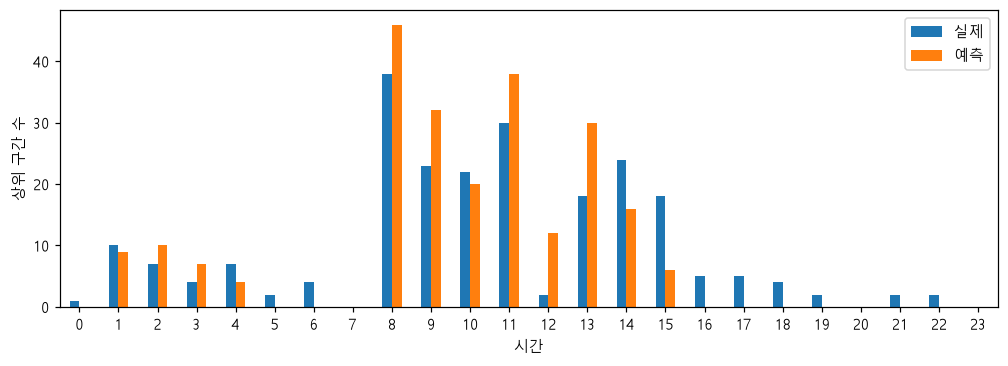

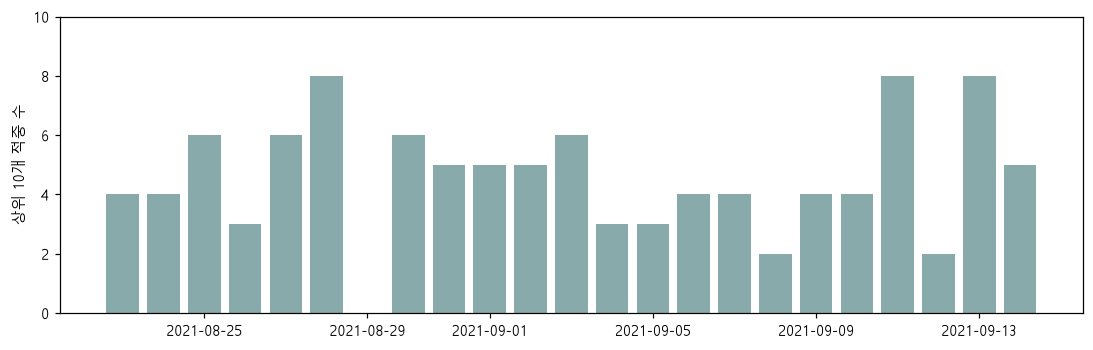

C:\Users\82105\AppData\Local\Temp\ipykernel_15932\2098012844.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(bd.sort_values(f"top{K}_hits").head(8).round(2))


,date,dow,mae,top10_hits,top10_hits_within_15min,top10_mae,daily_max_err,요일
6,2021-08-29,7,11.87,0,1,2.78,-16.54,일
16,2021-09-08,3,13.75,2,2,2.47,0.30,수
20,2021-09-12,7,0.93,2,5,2.10,-3.61,일
3,2021-08-26,4,9.85,3,7,20.26,-22.29,목
12,2021-09-04,6,7.31,3,6,6.62,-9.40,토
13,2021-09-05,7,1.07,3,5,2.47,-3.54,일
14,2021-09-06,1,8.41,4,6,2.41,-4.73,월
15,2021-09-07,2,10.71,4,8,11.26,-14.20,화


In [7]:
A = daily_matrix(preds, "kw")
P = daily_matrix(preds, selected)
top_a = np.argsort(-A.to_numpy(), axis=1, kind="stable")[:, :K] // 4
top_p = np.argsort(-P.to_numpy(), axis=1, kind="stable")[:, :K] // 4
dist = pd.DataFrame({"실제": np.bincount(top_a.ravel(), minlength=24),
                     "예측": np.bincount(top_p.ravel(), minlength=24)})
ax = dist.plot(kind="bar", figsize=(11, 3.5), rot=0)
ax.set_xlabel("시간")
ax.set_ylabel("상위 구간 수")
plt.show()

bd = sl["by_day"].assign(요일=lambda d: d["dow"].map(DOW_KR))
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(pd.to_datetime(bd["date"]), bd[f"top{K}_hits"], color="#8aa")
ax.set_ylim(0, K)
ax.set_ylabel(f"상위 {K}개 적중 수")
plt.show()
display(bd.sort_values(f"top{K}_hits").head(8).round(2))